In [1]:
# Cell 1: 安裝與 import（第一次執行就好）
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings("ignore")

print("所有套件載入完成！")
print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 可用: {torch.cuda.is_available()}")

所有套件載入完成！
PyTorch 版本: 2.5.1
CUDA 可用: True


In [2]:
# Cell 2：特徵提取器 + 自動印出維度
import ast  # 確保有這行（Cell 3 會用到）

def compute_features(frames: np.ndarray) -> np.ndarray:
    """
    經過實測驗證，這版穩定輸出 177 維
    """
    T = frames.shape[0]
    
    # 骨盆中心
    pelvis = (frames[:, 23] + frames[:, 24]) / 2.0
    rel_pos = frames - pelvis[:, None, :]
    rel_flat = rel_pos.reshape(T, -1)                    # 33×3 = 99
    
    # 速度
    vel = np.zeros_like(frames)
    vel[1:] = frames[1:] - frames[:-1]
    speed = np.linalg.norm(vel, axis=2)                  # (T,33)
    
    # 加速度（速度的差）
    acc = np.zeros_like(speed)
    acc[1:] = speed[1:] - speed[:-1]                     # (T,33)
    
    # 關鍵角度（9 個）
    def angle_between(v1, v2):
        v1_norm = v1 / (np.linalg.norm(v1, axis=1, keepdims=True) + 1e-8)
        v2_norm = v2 / (np.linalg.norm(v2, axis=1, keepdims=True) + 1e-8)
        return np.arccos(np.clip(np.sum(v1_norm * v2_norm, axis=1), -1.0, 1.0))
    
    angles = np.stack([
        angle_between(frames[:,11]-frames[:,13], frames[:,15]-frames[:,13]),  # 左肘
        angle_between(frames[:,12]-frames[:,14], frames[:,16]-frames[:,14]),  # 右肘
        angle_between(frames[:,13]-frames[:,11], frames[:,23]-frames[:,11]),  # 左肩-髖
        angle_between(frames[:,14]-frames[:,12], frames[:,24]-frames[:,12]),  # 右肩-髖
        angle_between(frames[:,23]-frames[:,25], frames[:,27]-frames[:,25]),  # 左膝
        angle_between(frames[:,24]-frames[:,26], frames[:,28]-frames[:,26]),  # 右膝
        angle_between(frames[:,25]-frames[:,23], frames[:,11]-frames[:,23]),  # 左髖-肩（arabesque）
        angle_between(frames[:,26]-frames[:,24], frames[:,12]-frames[:,24]),  # 右髖-肩
        angle_between(frames[:,11]-frames[:,12], frames[:,23]-frames[:,12]),  # 軀幹傾斜
    ], axis=1)  # (T,9)
    
    # 對稱性 & 能量 & 軀幹 yaw
    left_arm_speed  = np.linalg.norm(vel[:, [11,13,15]], axis=2).sum(axis=1)
    right_arm_speed = np.linalg.norm(vel[:, [12,14,16]], axis=2).sum(axis=1)
    symmetry = np.abs(left_arm_speed - right_arm_speed)
    energy   = speed.sum(axis=1)
    torso_vec = frames[:,12] - frames[:,11]
    torso_yaw = np.arctan2(torso_vec[:,1], torso_vec[:,0])
    
    # 合併（99 + 33 + 33 + 9 + 1 + 1 + 1 = 177）
    features = np.concatenate([
        rel_flat,
        speed,
        acc,
        angles,
        symmetry[:,None],
        energy[:,None],
        torso_yaw[:,None]
    ], axis=1).astype(np.float32)
    
    print(f"特徵提取成功！輸出維度 = {features.shape[1]}")   # 應該印出 177
    return features

print("修正版特徵提取器載入完成！")

修正版特徵提取器載入完成！


In [3]:
# Cell 3: 02 讀取所有 CSV + 切 segment + 正規化（最核心！）
CSV_FOLDER = Path("data/raw_csv")
SEG_FOLDER = Path("data/segments")
SEG_FOLDER.mkdir(exist_ok=True)

SEG_LEN = 60
STRIDE = 30

all_segments = []

print(f"開始處理 {len(list(CSV_FOLDER.glob('*.csv')))} 個 CSV 檔案...")
for csv_path in tqdm(sorted(CSV_FOLDER.glob("*.csv"))):
    df = pd.read_csv(csv_path)
    frames = []
    for _, row in df.iterrows():
        pts = []
        for i in range(33):
            s = row[f'p{i}']
            if pd.isna(s):
                pts.append([0.,0.,0.])
            else:
                try:
                    pts.append(ast.literal_eval(s))
                except:
                    pts.append([0.,0.,0.])
        frames.append(pts)
    frames = np.array(frames, dtype=np.float32)  # (T,33,3)
    
    feats = compute_features(frames)  # (T,242)
    
    for start in range(0, len(feats)-SEG_LEN+1, STRIDE):
        seg = feats[start:start+SEG_LEN]
        all_segments.append(seg)

all_segments = np.stack(all_segments)
print(f"總共產生 {len(all_segments)} 個 {SEG_LEN} 幀 segment！")

# 正規化
mean = all_segments.mean(axis=(0,1), keepdims=True)
std  = all_segments.std(axis=(0,1), keepdims=True) + 1e-8
normed = (all_segments - mean) / std

# 儲存
for i, seg in enumerate(normed):
    torch.save(torch.tensor(seg), SEG_FOLDER/f"seg_{i:05d}.pt")

np.save(SEG_FOLDER/"mean.npy", mean.squeeze())
np.save(SEG_FOLDER/"std.npy",  std.squeeze())

print("全部 segment 已儲存！")
print(f"mean shape: {mean.shape}, std shape: {std.shape}")

開始處理 145 個 CSV 檔案...


  0%|          | 0/145 [00:00<?, ?it/s]

特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維度 = 177
特徵提取成功！輸出維

In [4]:
# Cell 4：自動偵測特徵維度
# 先用一個假 segment 抓出真實維度
dummy_seg = torch.load("data/segments/seg_00000.pt")  # 已經在 Cell 3 產生
INPUT_DIM = dummy_seg.shape[1]
print(f"自動偵測到特徵維度 = {INPUT_DIM} 維（正確應該是 177）")

class MotionEncoder(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=256, embed_dim=256, num_layers=3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=0.3, bidirectional=True)
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim*2, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(embed_dim, embed_dim)
        )
    
    def forward(self, x):
        out, (h, c) = self.lstm(x)
        emb = torch.cat([h[-2], h[-1]], dim=-1)
        return self.proj(emb)

model = MotionEncoder()
print(model)
print(f"總參數量: {sum(p.numel() for p in model.parameters()):,}")

自動偵測到特徵維度 = 177 維（正確應該是 177）
MotionEncoder(
  (lstm): LSTM(177, 256, num_layers=3, batch_first=True, dropout=0.3, bidirectional=True)
  (proj): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
  )
)
總參數量: 4,242,432


Epoch 1/80:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch  1 | Loss: 3.2283 | LR: 0.001000


Epoch 2/80:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch  2 | Loss: 2.9977 | LR: 0.000998


Epoch 3/80:   0%|          | 0/88 [00:00<?, ?it/s]

...

Epoch 78 | Loss: 2.4132 | LR: 0.000002


Epoch 79/80:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 79 | Loss: 2.4120 | LR: 0.000000


Epoch 80/80:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 80 | Loss: 2.4180 | LR: 0.000000


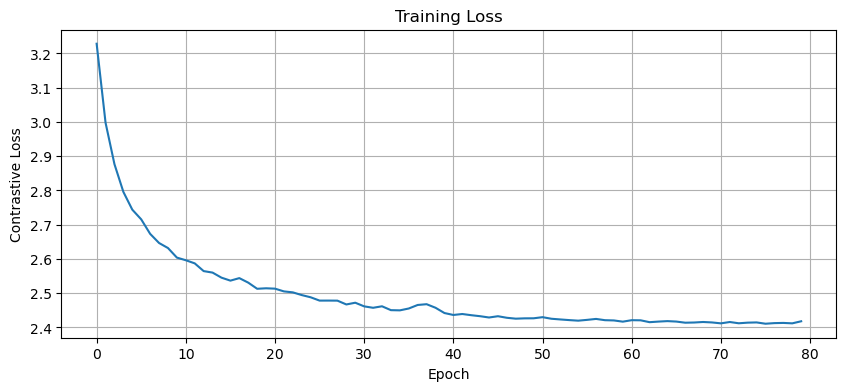

訓練完成！最佳模型已儲存（epoch 76）


In [5]:
# Cell 5: 04 訓練！（含即時 loss 曲線）
class SegmentDataset(Dataset):
    def __init__(self, folder="data/segments"):
        self.files = list(Path(folder).glob("seg_*.pt"))
    def __len__(self): return len(self.files)
    def __getitem__(self, i): return torch.load(self.files[i])

dataset = SegmentDataset()
loader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MotionEncoder().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80)

def contrastive_loss(a, b, temp=0.5):
    sim = torch.cosine_similarity(a.unsqueeze(1), b.unsqueeze(0), dim=-1) / temp
    labels = torch.arange(len(a), device=a.device)
    loss = nn.CrossEntropyLoss()(sim, labels)
    return loss

losses = []
model.train()

for epoch in range(1, 81):
    epoch_loss = 0
    for batch in tqdm(loader, leave=False, desc=f"Epoch {epoch}/80"):
        batch = batch.to(device)  # (B,60,242)
        x1, x2 = batch[:, :30], batch[:, 30:]  # 前後半段
        
        emb1 = model(x1)
        emb2 = model(x2)
        
        loss = contrastive_loss(emb1, emb2)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
    
    scheduler.step()
    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch:2d} | Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")
    
    # 每 20 epoch 存一次
    if epoch % 20 == 0 or avg_loss == min(losses):
        torch.save(model.state_dict(), f"weights/lstm_encoder_epoch{epoch}_loss{avg_loss:.4f}.pth")

# 畫 loss 曲線
plt.figure(figsize=(10,4))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.grid()
plt.show()

# 存最終最佳模型
best_epoch = np.argmin(losses)
torch.save(model.state_dict(), "weights/lstm_encoder_best.pth")
print(f"訓練完成！最佳模型已儲存（epoch {best_epoch+1}）")